In [16]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#23456789
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skbio
from skbio import DNA, Table
from skbio.metadata import SampleMetadata

skbio.__version__

'0.7.1.post1'

In [2]:
!ls ../../data

emp500  il6.ffn


In [3]:
DATA = '../../data/emp500'

In [4]:
!ls $DATA

amplicon   assembly   masspec    README.md  sample.tsv shotgun


In [5]:
!head $DATA/README.md

# The EMP500 Dataset

The Earth Microbiome Project 500 (EMP500) was a multi-omic study of microbial
communities sampled from various biomes and habitats of the planet. The study
was published in:

- Shaffer, J. P., Nothias, L. F., Thompson, L. R., Sanders, J. G., Salido, R.
  A., Couvillion, S. P., ... & Knight, R. (2022). Standardized multi-omics of
  Earth’s microbiomes reveals microbial and metabolite diversity. Nature
  Microbiology, 7(12), 2128-2150.


### Sample metadata

In [6]:
meta = pd.read_csv(f'{DATA}/sample.tsv', sep='\t', index_col=0)
meta.head()

,sample_name_original,sample_type,collection_timestamp,country,depth_sample,description,elevation,emp500_principal_investigator,emp500_study_id,emp500_pi_study_id,...,env_feature,env_material,env_package,geo_loc_name,host_subject_id,host_scientific_name,latitude,longitude,project_name,scientific_name
sample_name,,,,,,,,,,,,,,,,,,,,,
13114.angenent.65.s001,Angenent65.misc.104,bioreactor sludge,08/09/2011 0:00,USA - New York,not applicable,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,not applicable,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s002,Angenent65.misc.519,bioreactor sludge,9/27/12 0:00,USA - New York,not applicable,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.519,not applicable,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s003,Angenent65.misc.946,bioreactor sludge,11/28/13 0:00,USA - New York,not applicable,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,not applicable,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s004,Angenent65.misc.1022,bioreactor sludge,02/12/2014 0:00,USA - New York,not applicable,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.519,not applicable,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s005,Angenent65.misc.1538,bioreactor sludge,7/13/15 0:00,USA - New York,not applicable,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.1538,not applicable,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome


In [7]:
meta = SampleMetadata.load(
    f'{DATA}/sample.tsv', default_missing_scheme='INSDC:missing')
print(type(meta))
meta

<class 'skbio.metadata._metadata.SampleMetadata'>


SampleMetadata
--------------
880 IDs x 33 columns
sample_name_original:          ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
sample_type:                   ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
collection_timestamp:          ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
country:                       ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
depth_sample:                  ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
description:                   ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
elevation:                     ColumnProperties(type='numeric', missing_scheme='INSDC:missing')
emp500_principal_investigator: ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
emp500_study_id:               ColumnProperties(type='numeric', missing_scheme='INSDC:missing')
emp500_pi_study_id:            ColumnProperties(type='cat

In [8]:
df = meta.to_dataframe()
df.head(3)

,sample_name_original,sample_type,collection_timestamp,country,depth_sample,description,elevation,emp500_principal_investigator,emp500_study_id,emp500_pi_study_id,...,env_feature,env_material,env_package,geo_loc_name,host_subject_id,host_scientific_name,latitude,longitude,project_name,scientific_name
sample_name,,,,,,,,,,,,,,,,,,,,,
13114.angenent.65.s001,Angenent65.misc.104,bioreactor sludge,08/09/2011 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s002,Angenent65.misc.519,bioreactor sludge,9/27/12 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.519,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s003,Angenent65.misc.946,bioreactor sludge,11/28/13 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome


### Metadata Column

In [9]:
empo2 = meta.get_column('empo_2')
empo2

<CategoricalMetadataColumn name='empo_2' id_count=880>

In [10]:
s = empo2.to_series()
s

sample_name
13114.angenent.65.s001    Animal
13114.angenent.65.s002    Animal
13114.angenent.65.s003    Animal
13114.angenent.65.s004    Animal
13114.angenent.65.s005    Animal
                           ...  
13114.zaneveld.9.s018     Animal
13114.zaneveld.9.s019     Animal
13114.zaneveld.9.s020     Animal
13114.zaneveld.9.s021     Saline
13114.zaneveld.9.s022     Saline
Name: empo_2, Length: 880, dtype: object

In [11]:
empo2_freqs = s.value_counts()
empo2_freqs

empo_2
Non-saline    343
Animal        301
Plant         115
Saline        109
Fungus         12
Name: count, dtype: int64

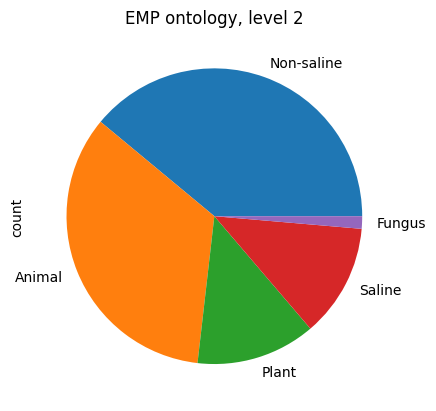

In [12]:
empo2_freqs.plot.pie(title='EMP ontology, level 2');

In [13]:
!ls $DATA/amplicon

16s.biom 16s.fa   16s.nwk  16s.tax  16s.tsv  subset


### Sequences

In [14]:
!head -6 $DATA/amplicon/16s.fa

>00006499
AAACCAGCACCTCAAGTGGTCAGGAGGATTATTGGGCCTAAAGCATCCGTAGCCGGCTCTGTAAGTTTTCGGTTAAATCCATGTGCTCAACGCATGGGCTGCCGAAAATACTGCATAGCTAGGGAGTGGGAGAGGTAGACGGTACTCAGT
>00012890
AAAGTAGGAGACGAGCGTTATCCGGATTTACTGGGCGTAAAGCGTGTGCAGGCGGTTCGGCAAGTTGGATGTGAAATCTCCCGGCTCAACTGGGAGGGGTCGTTCAATACTACCAAACTTGAGGGCATCAGAGGAAGGTGGAATTCCGGG
>00012904
AAAGTAGGATCCGAGCGTTATCCGAATTTACTGGGCGTAAAGCGCGTGCAGGCGGTTCGGTAAGTTGGATGTGAAAGCTCCCGGCTCAACTGGGAGAGGTCGTTCAATACTGCCGGACTCGAGGATGGTAGAGGGAGGTGGAATTCCCGG


In [15]:
DNA.read(f'{DATA}/amplicon/16s.fa')

DNA
---------------------------------------------------------------------
Metadata:
    'description': ''
    'id': '00006499'
Stats:
    length: 150
    has gaps: False
    has degenerates: False
    has definites: True
    GC-content: 50.67%
---------------------------------------------------------------------
0   AAACCAGCAC CTCAAGTGGT CAGGAGGATT ATTGGGCCTA AAGCATCCGT AGCCGGCTCT
60  GTAAGTTTTC GGTTAAATCC ATGTGCTCAA CGCATGGGCT GCCGAAAATA CTGCATAGCT
120 AGGGAGTGGG AGAGGTAGAC GGTACTCAGT

### Data table

In [17]:
table = Table.read(f'{DATA}/amplicon/16s.biom')
table

427269 x 805 <class 'biom.table.Table'> with 847146 nonzero entries (0% dense)

In [18]:
table.ids('sample')[:10]

array(['13114.song.51.s009', '13114.minich.76.s006',
       '13114.stegen.38.s015', '13114.song.52.s002',
       '13114.mousseau.88.s056', '13114.mcmahon.21.s002',
       '13114.myrold.5.s008', '13114.song.51.s012', '13114.king.27.s017',
       '13114.stegen.36.s004'], dtype='<U48')

In [19]:
set(table.ids('sample')).issubset(meta.ids)

True

In [21]:
set(table.ids('sample')) <= set(meta.ids)

True

In [22]:
table.ids('observation')[:10]

array(['08665176', '13062664', '03483654', '21781706', '07176695',
       '18439252', '08434208', '07654326', '22343722', '13688331'],
      dtype='<U8')

### Sparse data